# 1D Unit Random Walk (Demo)

This notebook is a lightweight demo.
Change the parameters below, rerun all cells, and inspect the saved outputs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils import (
    compute_unit_metrics,
    ensure_output_dirs,
    plot_histogram,
    plot_overlay_1d,
    plot_single_walk_1d,
    run_unit_walk_trials,
    save_summary_csv,
    simulate_unit_walk_1d,
)

# Demo knobs: tweak these and rerun the notebook.
RANDOM_SEED = 42
N_TRIALS = 10
MAX_STEPS = 20_000

NOTEBOOK_DIR = Path(".")
OUTPUT_DIR, PATHS_DIR = ensure_output_dirs(NOTEBOOK_DIR / "outputs" / "unit_walk_1D")

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(RANDOM_SEED)

print(f"Output folder: {OUTPUT_DIR.resolve()}")
print(f"RANDOM_SEED={RANDOM_SEED}, N_TRIALS={N_TRIALS}, MAX_STEPS={MAX_STEPS}")

Output folder: /home/manpazito/projects/fun_mini_sims/random_walks/outputs/unit_walk_1D
RANDOM_SEED=42, N_TRIALS=10, MAX_STEPS=20000


## Walk Model

- Start at `x = 0`
- Each step is `+1` or `-1` with equal probability
- Stop at first return to `x = 0` after leaving it (or at `MAX_STEPS`)

## Single Example Walk

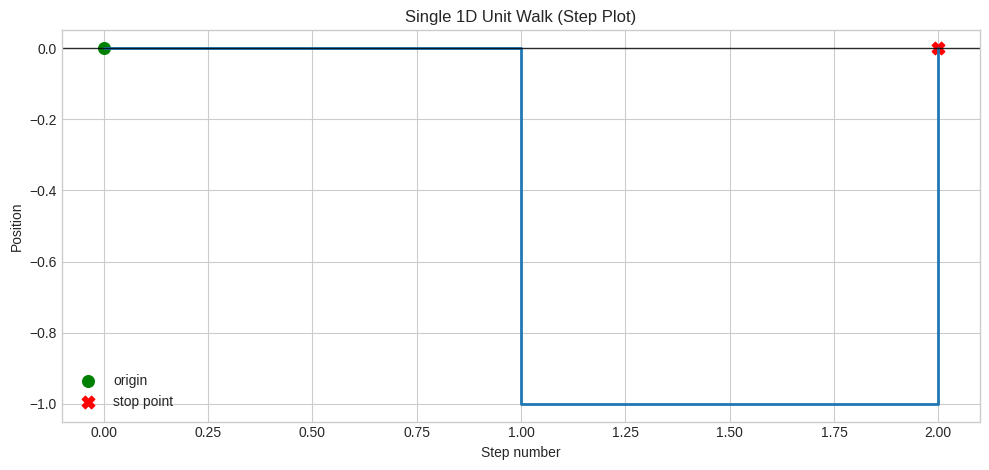

Single walk:
  steps_until_stop: 2
  returned_to_origin: True
  saved: outputs/unit_walk_1D/single_walk.png


In [2]:
single_walk = simulate_unit_walk_1d(rng=rng, max_steps=MAX_STEPS)

single_walk_plot_path = OUTPUT_DIR / "single_walk.png"
plot_single_walk_1d(
    positions=single_walk["positions"],
    out_path=single_walk_plot_path,
    title="Single 1D Unit Walk (Step Plot)",
)

print("Single walk:")
print(f"  steps_until_stop: {single_walk['steps_until_stop']}")
print(f"  returned_to_origin: {single_walk['returned_to_origin']}")
print(f"  saved: {single_walk_plot_path}")

## Monte Carlo Simulation

We can simulate this many times to see the results of many different simulations.

In [3]:
summary_df, all_paths = run_unit_walk_trials(
    rng=rng,
    n_trials=N_TRIALS,
    max_steps=MAX_STEPS,
    paths_dir=PATHS_DIR,
)

summary_csv_path = save_summary_csv(summary_df, OUTPUT_DIR / "summary.csv")
metrics = compute_unit_metrics(summary_df)

print("Monte Carlo summary:")
print(f"  completed_trials: {metrics['completed_trials']}")
print(f"  censored_trials: {metrics['censored_trials']}")
print(f"  mean_return_time: {metrics['mean_return_time']:.3f}")
print(f"  variance_return_time: {metrics['variance_return_time']:.3f}")
print(f"  mean_max_abs_displacement: {metrics['mean_max_abs_displacement']:.3f}")
print(f"  saved: {summary_csv_path}")

summary_df.head()

Monte Carlo summary:
  completed_trials: 10
  censored_trials: 0
  mean_return_time: 22.800
  variance_return_time: 1753.956
  mean_max_abs_displacement: 3.400
  saved: outputs/unit_walk_1D/summary.csv


,trial_index,steps_until_stop,return_time,returned_to_origin,censored,max_abs_displacement,min_position,max_position,final_position
0,0,2,2.0,True,False,1.0,0,1,0
1,1,2,2.0,True,False,1.0,-1,0,0
2,2,2,2.0,True,False,1.0,-1,0,0
3,3,4,4.0,True,False,2.0,-2,0,0
4,4,66,66.0,True,False,9.0,0,9,0


### Distribution Plots

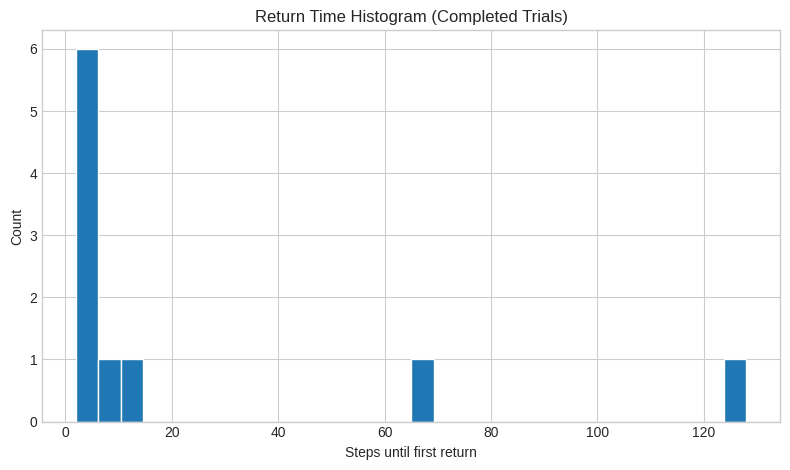

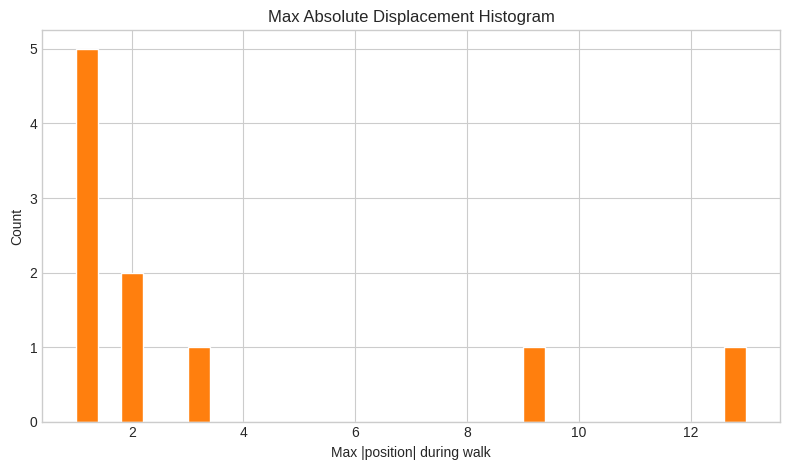

saved: outputs/unit_walk_1D/return_time_histogram.png
saved: outputs/unit_walk_1D/max_distance_histogram.png


In [4]:
completed_return_times = summary_df.loc[~summary_df["censored"], "return_time"]

return_hist_path = OUTPUT_DIR / "return_time_histogram.png"
max_dist_hist_path = OUTPUT_DIR / "max_distance_histogram.png"

plot_histogram(
    values=completed_return_times,
    out_path=return_hist_path,
    title="Return Time Histogram (Completed Trials)",
    xlabel="Steps until first return",
    color="tab:blue",
)

plot_histogram(
    values=summary_df["max_abs_displacement"],
    out_path=max_dist_hist_path,
    title="Max Absolute Displacement Histogram",
    xlabel="Max |position| during walk",
    color="tab:orange",
)

print(f"saved: {return_hist_path}")
print(f"saved: {max_dist_hist_path}")

### Final Overlay Plot

All walks are overlaid on one figure.


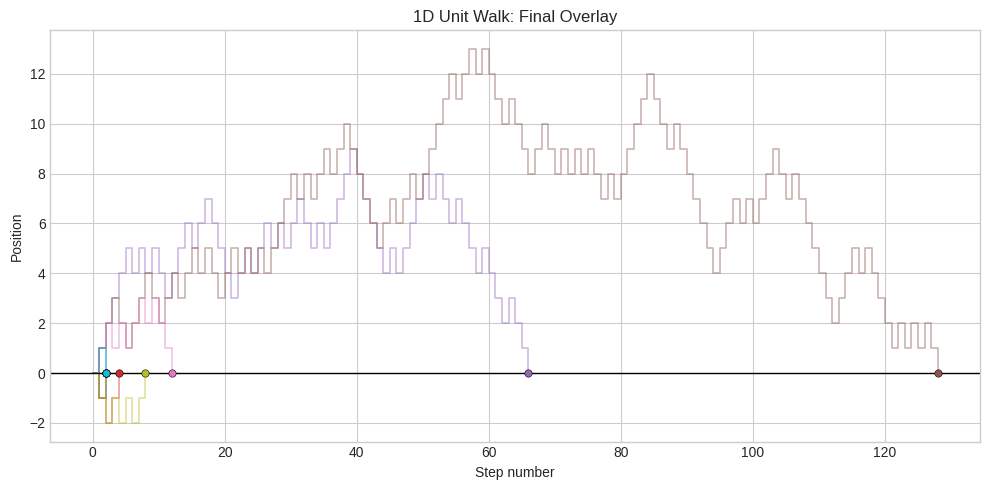

total_walks=10
saved: outputs/unit_walk_1D/overlay_walks.png


In [5]:
overlay_path = OUTPUT_DIR / "overlay_walks.png"
plot_overlay_1d(
    all_paths=all_paths,
    out_path=overlay_path,
    title="1D Unit Walk: Final Overlay",
)
print(f"total_walks={len(all_paths)}")
print(f"saved: {overlay_path}")